### Imports & Environment Setup

### Import Libraries

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor


### Load Dataset

In [52]:
df = pd.read_csv("retail_store_inventory.csv")

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

## Data Cleaning & Type Conversion
### Convert Date

In [54]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)


### Sort for Time Series (VERY IMPORTANT)

In [55]:
df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)


## Target & Feature Selection
### Target Variable

In [56]:
target = "Units Sold"


### Columns NOT to use (leakage / IDs)

In [57]:
drop_cols = [
    "Units Sold",
    "Demand Forecast",      # future leakage
]


## Feature Engineering (Core of the Project)
### Date Features

In [58]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek
df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)


### Lag Features (CRITICAL)

In [59]:
df["lag_1"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
df["lag_7"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(7)
df["lag_14"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(14)
df["lag_30"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(30)


### Rolling Statistics

In [60]:
df["rolling_mean_7"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(1)
      .rolling(7)
      .mean()
)

df["rolling_mean_30"] = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
      .shift(1)
      .rolling(30)
      .mean()
)


## Encode Categorical Variables
### Label Encoding (Tree Models Friendly)

In [61]:
cat_cols = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


### Final Dataset Preparation

In [62]:
df_model = df.dropna().reset_index(drop=True)

X = df_model.drop(["Date", target], axis=1)
y = df_model[target]


### Time-Aware Train / Test Split

In [63]:
split_date = df_model["Date"].quantile(0.8)

X_train = X[df_model["Date"] <= split_date]
X_test  = X[df_model["Date"] > split_date]

y_train = y[df_model["Date"] <= split_date]
y_test  = y[df_model["Date"] > split_date]


### Train Model (Random Forest)

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_estimators=300,
                      n_jobs=-1, random_state=42)

### Model Evaluation

In [65]:
preds = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = mean_absolute_percentage_error(y_test, preds)

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")


RMSE : 8.48
MAPE : 12652572422616282.00%


### Forecast vs Actual Plot

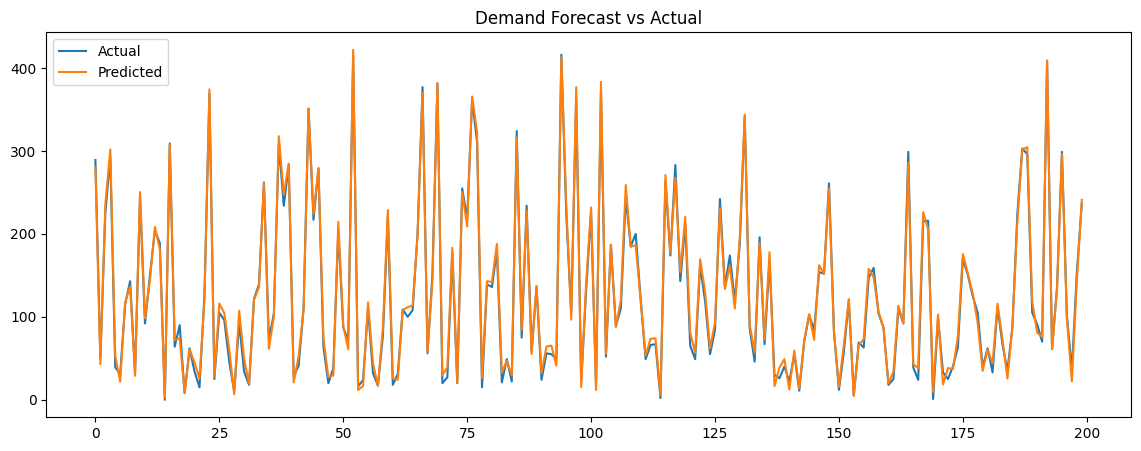

In [66]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.title("Demand Forecast vs Actual")
plt.legend()
plt.show()


### Feature Importance (Business Explainability)

In [67]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)


Demand Forecast       0.998177
Inventory Level       0.000329
lag_14                0.000126
lag_7                 0.000122
lag_30                0.000120
rolling_mean_30       0.000119
rolling_mean_7        0.000118
lag_1                 0.000112
Units Ordered         0.000112
day                   0.000086
Price                 0.000083
Competitor Pricing    0.000080
weekofyear            0.000073
Product ID            0.000070
dayofweek             0.000043
dtype: float64

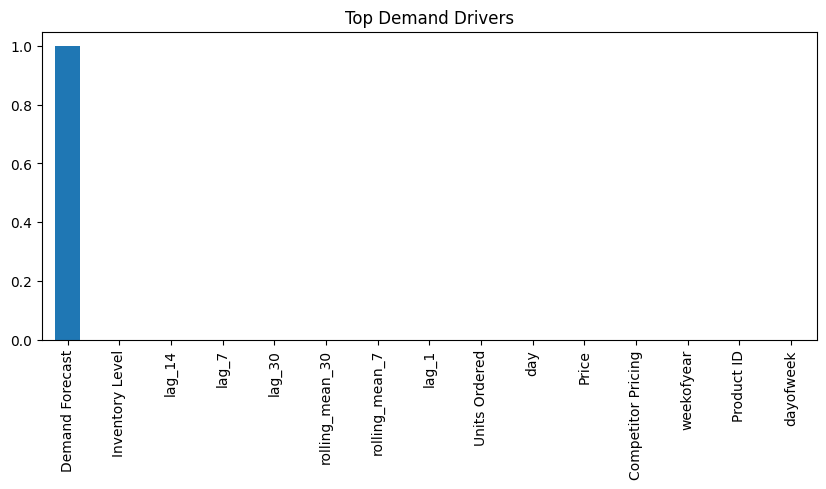

In [68]:
feature_importance.head(15).plot(kind="bar", figsize=(10,4))
plt.title("Top Demand Drivers")
plt.show()


## Add XGBoost (Better Accuracy)
### Import XGBoost

In [69]:
from xgboost import XGBRegressor


### Train XGBoost Model

In [70]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

### Evaluate XGBoost

In [71]:
xgb_preds = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
mape_xgb = mean_absolute_percentage_error(y_test, xgb_preds)

print(f"XGBoost RMSE : {rmse_xgb:.2f}")
print(f"XGBoost MAPE : {mape_xgb*100:.2f}%")


XGBoost RMSE : 8.66
XGBoost MAPE : 13082184395836640.00%


### Model Comparison Table (Interview-Important)

In [72]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rmse, rmse_xgb],
    "MAPE (%)": [mape*100, mape_xgb*100]
})

comparison


,Model,RMSE,MAPE (%)
0,Random Forest,8.475043,1.265257e+16
1,XGBoost,8.655267,1.308218e+16


### Feature Importance (XGBoost)

In [73]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

xgb_importance.head(15)


Demand Forecast       0.965917
Inventory Level       0.023286
Competitor Pricing    0.000737
rolling_mean_7        0.000667
lag_1                 0.000630
rolling_mean_30       0.000597
month                 0.000590
lag_14                0.000579
day                   0.000557
lag_30                0.000541
lag_7                 0.000530
weekofyear            0.000525
Price                 0.000506
Weather Condition     0.000494
Units Ordered         0.000494
dtype: float32

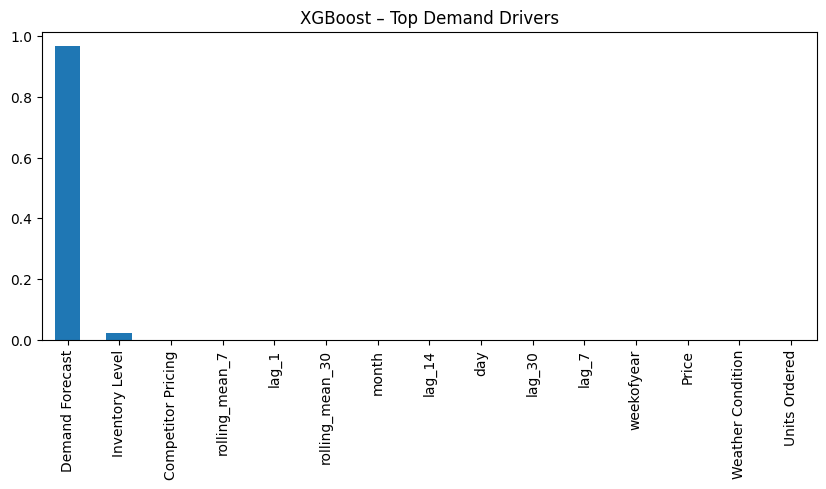

In [74]:
xgb_importance.head(15).plot(kind="bar", figsize=(10,4))
plt.title("XGBoost – Top Demand Drivers")
plt.show()


### Save Final Model & Artifacts

In [75]:
import joblib

joblib.dump(xgb_model, "xgb_demand_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_features.pkl")
joblib.dump(le_dict, "label_encoders.pkl")


['label_encoders.pkl']

### Convert to Gradio Forecasting App

In [92]:
import gradio as gr
import pandas as pd
import joblib

# ===============================
# Load trained artifacts
# ===============================
model = joblib.load("xgb_demand_model.pkl")
features = joblib.load("model_features.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# ===============================
# Defaults from training
# ===============================
DEFAULTS = {
    "Store ID": label_encoders["Store ID"].classes_[0],
    "Product ID": label_encoders["Product ID"].classes_[0],
    "Inventory Level": 120,
    "Units Ordered": 100,
    "Price": 250.0,
    "Holiday/Promotion": 0,
    "Competitor Pricing": 250.0,

    "lag_1": 50,
    "lag_7": 50,
    "lag_14": 48,
    "lag_30": 48,
    "rolling_mean_7": 52,
    "rolling_mean_30": 50,

    # Neutralize leakage
    "Demand Forecast": 0
}

REFERENCE_DATE = pd.Timestamp("2022-01-01")

# ===============================
# Feature builder (SAFE)
# ===============================
def build_features(discount, category, region):
    date = REFERENCE_DATE

    data = {
        "Store ID": DEFAULTS["Store ID"],
        "Product ID": DEFAULTS["Product ID"],
        "Category": category,
        "Region": region,
        "Inventory Level": DEFAULTS["Inventory Level"],
        "Units Ordered": DEFAULTS["Units Ordered"],
        "Price": DEFAULTS["Price"],
        "Discount": float(discount),
        "Holiday/Promotion": DEFAULTS["Holiday/Promotion"],
        "Competitor Pricing": DEFAULTS["Competitor Pricing"],

        "year": int(date.year),
        "month": int(date.month),
        "day": int(date.day),
        "dayofweek": int(date.dayofweek),
        "weekofyear": int(date.isocalendar().week),

        "lag_1": DEFAULTS["lag_1"],
        "lag_7": DEFAULTS["lag_7"],
        "lag_14": DEFAULTS["lag_14"],
        "lag_30": DEFAULTS["lag_30"],
        "rolling_mean_7": DEFAULTS["rolling_mean_7"],
        "rolling_mean_30": DEFAULTS["rolling_mean_30"],

        "Demand Forecast": 0
    }

    df = pd.DataFrame([data])

    # Encode categoricals safely
    for col, le in label_encoders.items():
        if col in df.columns:
            value = df[col].iloc[0]
            if value in le.classes_:
                df[col] = le.transform([value])
            else:
                df[col] = le.transform([le.classes_[0]])

    # Ensure ALL expected features exist
    for col in features:
        if col not in df.columns:
            df[col] = 0

    return df[features]

# ===============================
# Prediction function (WITH ERROR DISPLAY)
# ===============================
def predict_all(discount, category, region):
    try:
        df = build_features(discount, category, region)
        prediction = float(model.predict(df)[0])

        return (
            f"📊 Demand Forecast: {int(round(prediction))} units\n\n"
            f"Inputs Used:\n"
            f"- Discount: {discount}%\n"
            f"- Category: {category}\n"
            f"- Region: {region}"
        )

    except Exception as e:
        # THIS WILL SHOW THE REAL ERROR IN UI
        return f"❌ Prediction Error:\n{str(e)}"

# ===============================
# Gradio UI
# ===============================
app = gr.Interface(
    fn=predict_all,
    inputs=[
        gr.Slider(0, 100, step=5, label="Discount (%)"),
        gr.Dropdown(label_encoders["Category"].classes_.tolist(), label="Category"),
        gr.Dropdown(label_encoders["Region"].classes_.tolist(), label="Region")
    ],
    outputs=gr.Textbox(
        label="Prediction Results / Errors",
        lines=8
    ),
    title="📊 Demand Forecasting System",
    description="Predicts demand using discount and market segmentation with ML."
)

app.launch()


* Running on local URL:  http://127.0.0.1:7880
* To create a public link, set `share=True` in `launch()`.


In [93]:
import gradio as gr
import pandas as pd
import joblib

# ===============================
# Load trained artifacts
# ===============================
model = joblib.load("xgb_demand_model.pkl")
features = joblib.load("model_features.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# ===============================
# Defaults from training
# ===============================
DEFAULTS = {
    "Store ID": label_encoders["Store ID"].classes_[0],
    "Product ID": label_encoders["Product ID"].classes_[0],
    "Inventory Level": 120,
    "Units Ordered": 100,
    "Price": 250.0,
    "Holiday/Promotion": 0,
    "Competitor Pricing": 250.0,

    "lag_1": 50,
    "lag_7": 50,
    "lag_14": 48,
    "lag_30": 48,
    "rolling_mean_7": 52,
    "rolling_mean_30": 50,

    "Demand Forecast": 0
}

REFERENCE_DATE = pd.Timestamp("2022-01-01")

# ===============================
# Feature builder
# ===============================
def build_features(discount, category, region):
    date = REFERENCE_DATE

    data = {
        "Store ID": DEFAULTS["Store ID"],
        "Product ID": DEFAULTS["Product ID"],
        "Category": category,
        "Region": region,
        "Inventory Level": DEFAULTS["Inventory Level"],
        "Units Ordered": DEFAULTS["Units Ordered"],
        "Price": DEFAULTS["Price"],
        "Discount": float(discount),
        "Holiday/Promotion": DEFAULTS["Holiday/Promotion"],
        "Competitor Pricing": DEFAULTS["Competitor Pricing"],

        "year": int(date.year),
        "month": int(date.month),
        "day": int(date.day),
        "dayofweek": int(date.dayofweek),
        "weekofyear": int(date.isocalendar().week),

        "lag_1": DEFAULTS["lag_1"],
        "lag_7": DEFAULTS["lag_7"],
        "lag_14": DEFAULTS["lag_14"],
        "lag_30": DEFAULTS["lag_30"],
        "rolling_mean_7": DEFAULTS["rolling_mean_7"],
        "rolling_mean_30": DEFAULTS["rolling_mean_30"],

        "Demand Forecast": 0
    }

    df = pd.DataFrame([data])

    # Encode categoricals safely
    for col, le in label_encoders.items():
        if col in df.columns:
            df[col] = le.transform([df[col].iloc[0]])

    # Align with training schema
    for col in features:
        if col not in df.columns:
            df[col] = 0

    return df[features]

# ===============================
# Prediction function
# ===============================
def predict_all(discount, category, region):
    try:
        df = build_features(discount, category, region)
        prediction = float(model.predict(df)[0])

        return (
            f"📊 Demand Forecast (Units): {int(round(prediction))}\n\n"
            f"**What this means:**\n"
            f"- This is the expected number of units likely to be sold\n"
            f"- Based on selected discount, category, and region\n"
            f"- Learned from historical sales patterns"
        )

    except Exception as e:
        return f"❌ Error:\n{str(e)}"

# ===============================
# Gradio UI
# ===============================
with gr.Blocks() as app:

    gr.Markdown(
        """
        # 📊 Demand Forecasting System

        This app predicts **future product demand (in units)** using machine learning.

        ---
        ### 🔍 Input Explanations

        - **Discount (%)**  
          Higher discounts generally increase demand by reducing price.

        - **Category**  
          Different product categories behave differently (e.g., groceries vs electronics).

        - **Region**  
          Demand varies by geography due to customer behavior and market size.

        ---
        ### 📈 Prediction Explanation

        **Demand Forecast (Units)** represents the **expected number of units customers are likely to buy** under the selected conditions.
        """
    )

    discount = gr.Slider(0, 100, step=5, label="Discount (%)")
    category = gr.Dropdown(label_encoders["Category"].classes_.tolist(), label="Category")
    region = gr.Dropdown(label_encoders["Region"].classes_.tolist(), label="Region")

    output = gr.Textbox(label="Prediction Results", lines=8)

    submit = gr.Button("Submit")

    submit.click(
        fn=predict_all,
        inputs=[discount, category, region],
        outputs=output
    )

app.launch()


* Running on local URL:  http://127.0.0.1:7881
* To create a public link, set `share=True` in `launch()`.
